In [ ]:
import sys, subprocess, importlib, warnings, time, os, random, json
warnings.filterwarnings("ignore")

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

for mod, pkg in [("rdkit", "rdkit"), ("shap", "shap"), ("requests", "requests")]:
    try:
        importlib.import_module(mod)
    except Exception:
        print(f"Installing {pkg} ...")
        _pip(pkg)

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score
from sklearn.decomposition import PCA

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, Draw, QED, rdMolDescriptors, BRICS, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog("rdApp.*")
try:
    from rdkit.Chem.MolStandardize import rdMolStandardize
    _HAS_STD = True
except Exception:
    _HAS_STD = False

try:
    from rdkit.Chem import RDConfig
    sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
    import sascorer
    _HAS_SA = True
except Exception:
    _HAS_SA = False

TARGET_CHEMBL_ID = "CHEMBL203"
TARGET_QUERY     = "Epidermal growth factor receptor"
FALLBACK_CHEMBL_ID = "CHEMBL203"
NBITS, RADIUS  = 2048, 2
RANDOM_STATE   = 42
MAX_ACTIVITIES = 9000
MAX_UNIQUE     = 4000
ACTIVE_PIC50   = 7.0
BRICS_MAX_TRIES = 4000
N_FRAG_PARENTS  = 60
N_SHORTLIST     = 12
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE)

BASE = "https://www.ebi.ac.uk/chembl/api/data"
HDRS = {"Accept": "application/json", "User-Agent": "ai-coscientist-tutorial/1.0"}

def banner(title):
    print("\n" + "=" * 86 + f"\n  {title}\n" + "=" * 86)

def http_json(url, params=None, tries=3, timeout=45):
    for k in range(tries):
        try:
            r = requests.get(url, params=params, headers=HDRS, timeout=timeout)
            if r.status_code == 200:
                return r.json()
            if r.status_code == 404:
                return None
        except Exception:
            pass
        time.sleep(1.5 * (k + 1))
    return None

banner("[1/9] TARGET INTELLIGENCE  (ChEMBL + UniProt)")
print("Question: What target are we drugging, and why is it hard?\n")

def ic50_count(tid):
    js = http_json(f"{BASE}/activity", {"target_chembl_id": tid, "standard_type": "IC50",
                                        "pchembl_value__isnull": "false", "limit": 1, "format": "json"})
    try:
        return int(js["page_meta"]["total_count"])
    except Exception:
        return 0

target_id, target_name, uniprot_acc = None, TARGET_QUERY, None
if TARGET_CHEMBL_ID:
    target_id = TARGET_CHEMBL_ID
else:
    srch = http_json(f"{BASE}/target/search", {"q": TARGET_QUERY, "format": "json"})
    cands = []
    if srch:
        for t in srch.get("targets", []):
            if t.get("organism") == "Homo sapiens" and t.get("target_type") == "SINGLE PROTEIN":
                cands.append(t)
    cands = sorted(cands, key=lambda t: float(t.get("score", 0)), reverse=True)[:8]
    scored = [(t, ic50_count(t["target_chembl_id"])) for t in cands]
    scored = [(t, n) for t, n in scored if n > 0]
    if scored:
        best = max(scored, key=lambda x: x[1])[0]
        target_id, target_name = best["target_chembl_id"], best.get("pref_name", TARGET_QUERY)
        print(f"  Auto-resolved '{TARGET_QUERY}' by data volume -> {target_id}")
    else:
        target_id = FALLBACK_CHEMBL_ID
        print(f"  Auto-resolve found no data; falling back to {FALLBACK_CHEMBL_ID}")

det = http_json(f"{BASE}/target/{target_id}", {"format": "json"})
if det and det.get("pref_name"):
    target_name = det["pref_name"]
if det:
    for comp in det.get("target_components", []):
        if comp.get("accession"):
            uniprot_acc = comp["accession"]; break

print(f"  Resolved target : {target_name}")
print(f"  ChEMBL ID       : {target_id}")
print(f"  UniProt         : {uniprot_acc}")

if uniprot_acc:
    uni = http_json(f"https://rest.uniprot.org/uniprotkb/{uniprot_acc}.json")
    if uni:
        try:
            fn = next(c["texts"][0]["value"] for c in uni.get("comments", [])
                      if c.get("commentType") == "FUNCTION")
            print("\n  Function (UniProt):")
            print("   ", (fn[:340] + " ...") if len(fn) > 340 else fn)
        except Exception:
            pass
print("""
  Resistance context: 1st/2nd/3rd-gen EGFR TKIs lose potency once tumours acquire the
  C797S mutation, which abolishes the covalent cysteine anchor exploited by osimertinib.
  Goal of this run: learn the chemistry of known EGFR inhibitors and propose NOVEL,
  drug-like analogs as starting points for a C797S-active 4th-generation series.""")

In [ ]:
banner("[2/9] BIOACTIVITY MINING  (ChEMBL activities -> pIC50)")
def pull_activities(tid, cap):
    url, rows = f"{BASE}/activity", []
    params = {"target_chembl_id": tid, "standard_type": "IC50",
              "pchembl_value__isnull": "false", "limit": 1000, "format": "json"}
    js = http_json(url, params)
    pages = 0
    while js and pages < 60:
        rows.extend(js.get("activities", []))
        pages += 1
        if len(rows) >= cap:
            break
        nxt = js.get("page_meta", {}).get("next")
        if not nxt:
            break
        nurl = nxt if nxt.startswith("http") else "https://www.ebi.ac.uk" + nxt
        js = http_json(nurl)
    return rows[:cap]

raw = pull_activities(target_id, MAX_ACTIVITIES)
print(f"  Pulled {len(raw)} raw IC50 records with a curated pChEMBL value.")

recs = []
for a in raw:
    smi, pv = a.get("canonical_smiles"), a.get("pchembl_value")
    if not smi or pv in (None, ""):
        continue
    if a.get("standard_relation") != "=":
        continue
    if a.get("standard_units") not in ("nM", None):
        continue
    try:
        pv = float(pv)
    except Exception:
        continue
    recs.append({"chembl_id": a.get("molecule_chembl_id"), "smiles": smi, "pIC50": pv})
raw_df = pd.DataFrame(recs, columns=["chembl_id", "smiles", "pIC50"])
print(f"  After quality filters: {len(raw_df)} measurements.")

if len(raw_df) == 0:
    print("\n  STOP: no usable IC50 data was retrieved for this target.\n"
          "  Fix: set TARGET_CHEMBL_ID to a target that has inhibitor data\n"
          "       (e.g. CHEMBL203=EGFR, CHEMBL5251=BTK, CHEMBL2971=JAK2),\n"
          "       or set TARGET_CHEMBL_ID=\"\" to auto-resolve TARGET_QUERY by data volume.")
    raise SystemExit("No bioactivity data for the selected target.")

banner("[3/9] MOLECULAR CURATION  (standardize, de-salt, aggregate)")
_lfc = rdMolStandardize.LargestFragmentChooser() if _HAS_STD else None
_unc = rdMolStandardize.Uncharger() if _HAS_STD else None

def standardize(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return None, None
    try:
        if _HAS_STD:
            m = _lfc.choose(m); m = _unc.uncharge(m)
        else:
            frags = Chem.GetMolFrags(m, asMols=True, sanitizeFrags=True)
            if frags:
                m = max(frags, key=lambda x: x.GetNumHeavyAtoms())
        return m, Chem.MolToSmiles(m)
    except Exception:
        return None, None

canon, keep_mol = [], {}
for _, r in raw_df.iterrows():
    m, cs = standardize(r["smiles"])
    if cs is None or m.GetNumHeavyAtoms() < 6:
        continue
    canon.append({"smiles": cs, "pIC50": r["pIC50"], "chembl_id": r["chembl_id"]})
    keep_mol[cs] = m
cdf = pd.DataFrame(canon, columns=["smiles", "pIC50", "chembl_id"])
data = (cdf.groupby("smiles")
        .agg(pIC50=("pIC50", "median"), n=("pIC50", "size"),
             chembl_id=("chembl_id", "first")).reset_index())
if len(data) > MAX_UNIQUE:
    data = data.sample(MAX_UNIQUE, random_state=RANDOM_STATE).reset_index(drop=True)
data["mol"] = data["smiles"].map(keep_mol)
n_active = int((data["pIC50"] >= ACTIVE_PIC50).sum())
print(f"  Unique curated molecules : {len(data)}")
print(f"  Potent actives (IC50<=100nM): {n_active}  ({100*n_active/len(data):.1f}%)")
print(f"  pIC50 range: {data.pIC50.min():.2f} - {data.pIC50.max():.2f}  "
      f"(median {data.pIC50.median():.2f})")

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=NBITS)
DESC = [("MolWt", Descriptors.MolWt), ("MolLogP", Descriptors.MolLogP),
        ("TPSA", Descriptors.TPSA), ("HBD", Descriptors.NumHDonors),
        ("HBA", Descriptors.NumHAcceptors), ("RotB", Descriptors.NumRotatableBonds),
        ("AromRings", Descriptors.NumAromaticRings), ("FracCSP3", Descriptors.FractionCSP3),
        ("HeavyAtoms", Descriptors.HeavyAtomCount),
        ("NumRings", lambda m: rdMolDescriptors.CalcNumRings(m))]
FEAT_NAMES = [f"bit_{i}" for i in range(NBITS)] + [n for n, _ in DESC]

def fp_array(m):
    a = np.zeros((NBITS,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(mfpgen.GetFingerprint(m), a)
    return a

def featurize(mols):
    Xb = np.zeros((len(mols), NBITS), dtype=np.int8)
    Xd = np.zeros((len(mols), len(DESC)), dtype=np.float32)
    for i, m in enumerate(mols):
        Xb[i] = fp_array(m)
        for j, (_, fn) in enumerate(DESC):
            try:
                Xd[i, j] = fn(m)
            except Exception:
                Xd[i, j] = 0.0
    return np.nan_to_num(np.hstack([Xb, Xd]).astype(np.float32))

X = featurize(list(data["mol"]))
y = data["pIC50"].values
print(f"  Feature matrix: {X.shape[0]} molecules x {X.shape[1]} features "
      f"({NBITS} ECFP bits + {len(DESC)} descriptors)")

In [ ]:
banner("[4/9] CHEMICAL SPACE & SCAFFOLD ANALYSIS")
def murcko(m):
    try:
        s = MurckoScaffold.GetScaffoldForMol(m)
        cs = Chem.MolToSmiles(s)
        return cs if cs else "(acyclic)"
    except Exception:
        return "(error)"
data["scaffold"] = data["mol"].map(murcko)
top_scaf = data["scaffold"].value_counts().head(10)
print("  Top recurring Murcko scaffolds (chemotype families):")
for i, (sc, c) in enumerate(top_scaf.items(), 1):
    print(f"   {i:2d}. n={c:4d}  {sc[:70]}")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
emb = pca.fit_transform(X[:, :NBITS])
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
sc0 = ax[0].scatter(emb[:, 0], emb[:, 1], c=y, cmap="viridis", s=10, alpha=0.6)
ax[0].set(title="Chemical space (ECFP-PCA), coloured by potency",
          xlabel=f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)",
          ylabel=f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
plt.colorbar(sc0, ax=ax[0], label="pIC50")
ax[1].hist(y, bins=40, color="#3b7dd8", edgecolor="white")
ax[1].axvline(ACTIVE_PIC50, color="crimson", ls="--", label=f"active cut (pIC50={ACTIVE_PIC50})")
ax[1].set(title="Potency distribution", xlabel="pIC50", ylabel="molecules"); ax[1].legend()
ax[2].barh([s[:22] + "..." for s in top_scaf.index[::-1]], top_scaf.values[::-1], color="#6c5ce7")
ax[2].set(title="Top 10 scaffolds", xlabel="count")
plt.tight_layout(); plt.savefig("fig1_chemical_space.png", dpi=120); plt.show()

banner("[5/9] INTERPRETABLE QSAR MODEL  (scaffold-split, leakage-free)")
def scaffold_split(scaffolds, test_frac=0.2, seed=RANDOM_STATE):
    groups = {}
    for i, s in enumerate(scaffolds):
        groups.setdefault(s, []).append(i)
    order = list(groups.values())
    random.Random(seed).shuffle(order)
    n_test = int(len(scaffolds) * test_frac)
    test, train = [], []
    for g in order:
        (test if len(test) < n_test else train).extend(g)
    return np.array(sorted(train)), np.array(sorted(test))

tr, te = scaffold_split(data["scaffold"].values, 0.2)
model = RandomForestRegressor(n_estimators=400, max_features="sqrt",
                              n_jobs=-1, random_state=RANDOM_STATE)
model.fit(X[tr], y[tr])
pred = model.predict(X[te])
r2 = r2_score(y[te], pred)
rmse = mean_squared_error(y[te], pred) ** 0.5
rho = spearmanr(y[te], pred).statistic
ycls = (y[te] >= ACTIVE_PIC50).astype(int)
auc = roc_auc_score(ycls, pred) if len(np.unique(ycls)) == 2 else float("nan")
print(f"  Held-out (new-scaffold) performance on {len(te)} molecules:")
print(f"     R^2            = {r2:.3f}")
print(f"     RMSE (pIC50)   = {rmse:.3f}   (~{rmse:.2f} log units)")
print(f"     Spearman rho   = {rho:.3f}")
print(f"     ROC-AUC active = {auc:.3f}   (ranking potent vs weak)")

model_full = RandomForestRegressor(n_estimators=400, max_features="sqrt",
                                   n_jobs=-1, random_state=RANDOM_STATE).fit(X, y)

In [ ]:
banner("[6/9] MODEL INTERPRETABILITY  (which substructures drive potency?)")
top_feat_idx, shap_ok = None, False
try:
    import shap
    samp = np.random.RandomState(RANDOM_STATE).choice(len(te), min(300, len(te)), replace=False)
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(X[te][samp])
    if isinstance(sv, list):
        sv = sv[0]
    imp = np.abs(sv).mean(0)
    shap_ok = True
    print("  Using SHAP TreeExplainer (mean |SHAP| over held-out molecules).")
except Exception as e:
    imp = model_full.feature_importances_
    print(f"  SHAP unavailable ({type(e).__name__}); using RandomForest importances.")

order = np.argsort(imp)[::-1]
top_feat_idx = [i for i in order[:25]]
top_desc = [(FEAT_NAMES[i], imp[i]) for i in order if i >= NBITS][:8]
top_bits = [i for i in order if i < NBITS][:6]
print("\n  Most influential physicochemical descriptors:")
for name, v in top_desc:
    print(f"     {name:12s}  importance={v:.4f}")

train_smis = list(data["smiles"].iloc[tr])
def bit_exemplar(bit):
    for smi in train_smis:
        m = Chem.MolFromSmiles(smi)
        if m is None:
            continue
        ao = rdFingerprintGenerator.AdditionalOutput(); ao.AllocateBitInfoMap()
        _ = mfpgen.GetFingerprint(m, additionalOutput=ao)
        bi = ao.GetBitInfoMap()
        if bit in bi and len(bi[bit]):
            atom, rad = bi[bit][0]
            atoms, bonds = {atom}, []
            if rad > 0:
                env = Chem.FindAtomEnvironmentOfRadiusN(m, rad, atom)
                bonds = list(env)
                for bidx in env:
                    b = m.GetBondWithIdx(bidx)
                    atoms.update((b.GetBeginAtomIdx(), b.GetEndAtomIdx()))
            try:
                return Draw.MolToImage(m, size=(300, 240),
                                       highlightAtoms=list(atoms), highlightBonds=bonds)
            except Exception:
                return None
    return None

try:
    imgs = [(b, bit_exemplar(b)) for b in top_bits]
    imgs = [(b, im) for b, im in imgs if im is not None]
    if imgs:
        fig, ax = plt.subplots(1, len(imgs), figsize=(3.1 * len(imgs), 3.3))
        if len(imgs) == 1:
            ax = [ax]
        for a, (b, im) in zip(ax, imgs):
            a.imshow(im); a.axis("off"); a.set_title(f"ECFP bit {b}\n(rank imp.)", fontsize=9)
        plt.suptitle("Substructures the model associates with potency", y=1.02)
        plt.tight_layout(); plt.savefig("fig2_potency_substructures.png", dpi=120, bbox_inches="tight")
        plt.show()
except Exception as e:
    print(f"  (substructure drawing skipped: {type(e).__name__})")

banner("[7/9] GENERATIVE DESIGN  (BRICS fragment recombination -> novel analogs)")
seed = data[data["pIC50"] >= ACTIVE_PIC50].copy()
seed["mw"] = seed["mol"].map(Descriptors.MolWt)
seed = seed[(seed.mw >= 250) & (seed.mw <= 500)].sort_values("pIC50", ascending=False).head(N_FRAG_PARENTS)
print(f"  Seeding generative design with {len(seed)} potent, drug-like parent molecules.")

frags = set()
for m in seed["mol"]:
    try:
        frags.update(BRICS.BRICSDecompose(m))
    except Exception:
        pass
frag_mols = [f for f in (Chem.MolFromSmiles(s) for s in frags) if f is not None]
print(f"  Fragment pool: {len(frag_mols)} BRICS fragments.")

known = set(data["smiles"])
gen = {}
try:
    for i, prod in enumerate(BRICS.BRICSBuild(frag_mols, scrambleReagents=True, maxDepth=2)):
        if i >= BRICS_MAX_TRIES:
            break
        try:
            prod.UpdatePropertyCache(strict=False)
            Chem.SanitizeMol(prod)
            cs = Chem.MolToSmiles(prod)
        except Exception:
            continue
        if cs in known or cs in gen:
            continue
        mw = Descriptors.MolWt(prod)
        if 250 <= mw <= 600 and 8 <= prod.GetNumHeavyAtoms() <= 45:
            gen[cs] = prod
except Exception as e:
    print(f"  (BRICS build ended early: {type(e).__name__})")
print(f"  Generated {len(gen)} unique, novel, size-reasonable virtual molecules.")

In [ ]:
banner("[8/9] MULTI-PARAMETER PRIORITISATION")
gsmiles = list(gen.keys())
gmols = [gen[s] for s in gsmiles]
gX = featurize(gmols)
gpred = model_full.predict(gX)

train_fps = [mfpgen.GetFingerprint(m) for m in data["mol"]]
def novelty(m):
    sims = DataStructs.BulkTanimotoSimilarity(mfpgen.GetFingerprint(m), train_fps)
    return 1.0 - (max(sims) if sims else 0.0)

def desirability(x, lo, hi, hard_lo=None, hard_hi=None):
    hl = hard_lo if hard_lo is not None else lo
    hh = hard_hi if hard_hi is not None else hi
    if x < lo:
        return float(np.clip((x - hl) / (lo - hl + 1e-9), 0, 1))
    if x > hi:
        return float(np.clip((hh - x) / (hh - hi + 1e-9), 0, 1))
    return 1.0

rows = []
for smi, m, pp in zip(gsmiles, gmols, gpred):
    mw, lp = Descriptors.MolWt(m), Descriptors.MolLogP(m)
    hbd, hba = Descriptors.NumHDonors(m), Descriptors.NumHAcceptors(m)
    tpsa, rotb = Descriptors.TPSA(m), Descriptors.NumRotatableBonds(m)
    try:
        qed = QED.qed(m)
    except Exception:
        qed = np.nan
    sa = sascorer.calculateScore(m) if _HAS_SA else np.nan
    lip = int(mw <= 500) + int(lp <= 5) + int(hbd <= 5) + int(hba <= 10)
    veber = (rotb <= 10) and (tpsa <= 140)
    nov = novelty(m)
    d_pot = desirability(pp, 7.5, 12, hard_lo=5.5)
    d_mw = desirability(mw, 250, 500, hard_lo=150, hard_hi=650)
    d_lp = desirability(lp, 1, 4, hard_lo=-1, hard_hi=6)
    d_sa = desirability(-(sa if not np.isnan(sa) else 3), -3.5, -1, hard_lo=-6)
    score = (0.40 * d_pot + 0.20 * (qed if not np.isnan(qed) else 0.5) +
             0.10 * d_mw + 0.10 * d_lp + 0.10 * d_sa + 0.10 * nov)
    rows.append(dict(smiles=smi, pred_pIC50=pp, MolWt=mw, MolLogP=lp, TPSA=tpsa,
                     HBD=hbd, HBA=hba, QED=qed, SA=sa, novelty=nov,
                     lipinski=lip, veber_ok=veber, score=score))
_CANDCOLS = ["smiles", "pred_pIC50", "MolWt", "MolLogP", "TPSA", "HBD", "HBA",
             "QED", "SA", "novelty", "lipinski", "veber_ok", "score"]
cand = pd.DataFrame(rows, columns=_CANDCOLS)

gate = cand[(cand.pred_pIC50 >= 6.5) & (cand.MolWt.between(250, 600)) &
            (cand.lipinski >= 3) & (cand.veber_ok) &
            ((cand.SA <= 6) | cand.SA.isna()) & (cand.novelty >= 0.35)]
gate = gate.sort_values("score", ascending=False).reset_index(drop=True)
print(f"  {len(gate)} of {len(cand)} generated molecules passed the developability gate.")
print(f"  (gate: predicted pIC50>=6.5, MW 250-600, <=1 Lipinski violation, Veber OK,")
print(f"         SA<=6, novelty>=0.35 vs all known EGFR inhibitors)\n")

shortlist = gate.head(N_SHORTLIST).copy()


  [1/9] TARGET INTELLIGENCE  (ChEMBL + UniProt)
Question: What target are we drugging, and why is it hard?

  Resolved target : Epidermal growth factor receptor
  ChEMBL ID       : CHEMBL203
  UniProt         : P00533

  Function (UniProt):
    Receptor tyrosine kinase binding ligands of the EGF family and activating several signaling cascades to convert extracellular cues into appropriate cellular responses (PubMed:10805725, PubMed:27153536, PubMed:2790960, PubMed:35538033). Known ligands include EGF, TGFA/TGF-alpha, AREG, epigen/EPGN, BTC/betacellulin, epiregulin/EREG and HBEG ...

  Resistance context: 1st/2nd/3rd-gen EGFR TKIs lose potency once tumours acquire the
  C797S mutation, which abolishes the covalent cysteine anchor exploited by osimertinib.
  Goal of this run: learn the chemistry of known EGFR inhibitors and propose NOVEL,
  drug-like analogs as starting points for a C797S-active 4th-generation series.

  [2/9] BIOACTIVITY MINING  (ChEMBL activities -> pIC50)
  Pulled 9

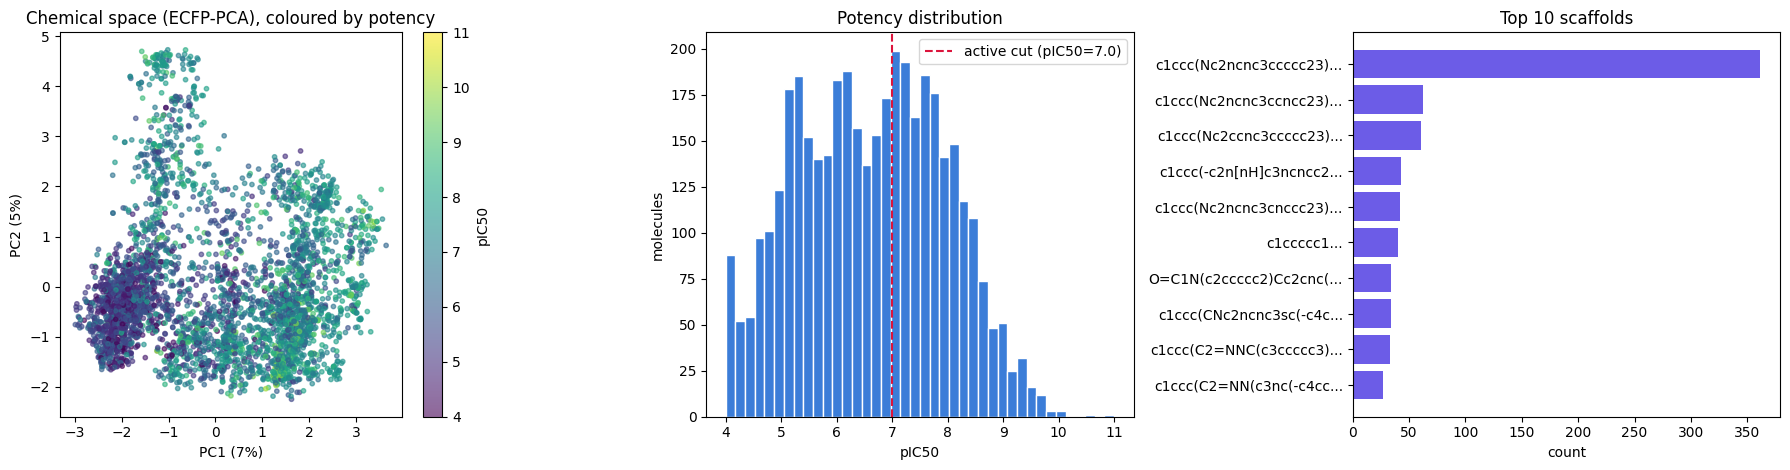


  [5/9] INTERPRETABLE QSAR MODEL  (scaffold-split, leakage-free)
  Held-out (new-scaffold) performance on 800 molecules:
     R^2            = 0.654
     RMSE (pIC50)   = 0.777   (~0.78 log units)
     Spearman rho   = 0.818
     ROC-AUC active = 0.919   (ranking potent vs weak)

  [6/9] MODEL INTERPRETABILITY  (which substructures drive potency?)


In [ ]:
banner("[9/9] NOVELTY CROSS-CHECK (PubChem) & FINAL SHORTLIST")
def pubchem_cid(smi):
    m = Chem.MolFromSmiles(smi)
    try:
        ik = Chem.MolToInchiKey(m)
    except Exception:
        return "inchikey_error"
    if not ik:
        return "inchikey_error"
    js = http_json(f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{ik}/cids/JSON")
    time.sleep(0.25)
    try:
        return f"CID {js['IdentifierList']['CID'][0]}"
    except Exception:
        return "NOT in PubChem (putatively new)"

shortlist["pubchem"] = shortlist["smiles"].map(pubchem_cid)

show_cols = ["pred_pIC50", "MolWt", "MolLogP", "QED", "SA", "novelty",
             "lipinski", "score", "pubchem"]
pretty = shortlist[show_cols].copy()
pretty.insert(0, "rank", range(1, len(pretty) + 1))
pd.set_option("display.width", 200, "display.max_colwidth", 40)
print("\nTOP CANDIDATE 4th-GENERATION EGFR-INHIBITOR STARTING POINTS:\n")
print(pretty.round(3).to_string(index=False))

try:
    mols = [Chem.MolFromSmiles(s) for s in shortlist["smiles"]]
    legs = [f"#{i+1}  pIC50~{r.pred_pIC50:.1f} | QED {r.QED:.2f} | nov {r.novelty:.2f}"
            for i, r in shortlist.reset_index().iterrows()]
    grid = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(300, 250), legends=legs)
    grid.save("fig3_top_candidates.png")
    try:
        from IPython.display import display
        display(grid)
    except Exception:
        plt.figure(figsize=(14, 9)); plt.imshow(grid); plt.axis("off"); plt.show()
except Exception as e:
    print(f"  (candidate drawing skipped: {type(e).__name__})")

shortlist.to_csv("egfr_coscientist_candidates.csv", index=False)

banner("AUTONOMOUS RESEARCH SUMMARY")
n_new = int((shortlist["pubchem"].str.startswith("NOT")).sum())
print(f"""  Target        : {target_name} ({target_id}) -- overcoming C797S resistance
  Evidence base : {len(data)} curated, de-duplicated EGFR inhibitors from ChEMBL
  Learned model : RandomForest QSAR, scaffold-split R^2={r2:.2f}, ROC-AUC={auc:.2f}
                  -> generalises to unseen chemotypes, not memorising analogs
  Key drivers   : {", ".join(n for n, _ in top_desc[:4])} + specific ECFP substructures
  Invented      : {len(gen)} novel virtual analogs via BRICS fragment recombination
  Prioritised   : {len(gate)} passed developability gates; top {len(shortlist)} shortlisted
  Novelty audit : {n_new}/{len(shortlist)} shortlisted molecules are absent from PubChem

  Artifacts written to disk:
    - egfr_coscientist_candidates.csv     (full scored shortlist)
    - fig1_chemical_space.png             (chemical space + potency + scaffolds)
    - fig2_potency_substructures.png      (SHAP-implicated substructures)
    - fig3_top_candidates.png             (structures of the shortlist)

  NEXT STEPS a wet-lab team would take: dock the shortlist into the EGFR(L858R/T790M/C797S)
  triple-mutant structure, prioritise allosteric binders, check synthetic routes, and
  assay the top ~5 for C797S potency and selectivity vs wild-type EGFR.

  Reminder: this is an educational in-silico hypothesis generator, not a validated drug
  pipeline. Predictions require experimental confirmation.""")
print("\nDONE.")